# MISO on Human Colon Cancer Visium HD

## Full-table, 2,000-HVG benchmark protocol

This notebook implements MISO using the supervisor-mandated input: the **complete**
`manual_analysis_count_area_filtered` table (131,592 observations) and **2,000 Seurat HVGs**.
It combines RNA expression with the H&E image
`Visium_HD_Human_Colon_Cancer_hires_image`.

MISO officially requires Python 3.7. This notebook must use the Jupyter kernel
**Python 3.7_MISO** (`python3.7_MISO` conda environment). The common SpatialData
input is exported once in Python 3.11 because current SpatialData releases do not
support Python 3.7. That export is data preparation, and is explicitly excluded from
MISO runtime benchmarking.

Important scalability note: MISO's official repository reports timings for datasets
below 10,000 spots. Its implementation trains for 1,000 full-batch epochs. This
notebook uses the official sparse-neighbour graph option to avoid the otherwise
impossible dense 131,592 x 131,592 affinity matrix, but a full CPU run remains a
high-resource experiment. No analytical cell subsets the table.


## 1. Environment and timing setup

Each substantive stage is wrapped in `record_step()` and saved to a CSV. In addition,
`autotime` prints elapsed time below every executed notebook cell.


In [1]:
%load_ext autotime

import json
import os
import platform
import random
import subprocess
import sys
import time
from contextlib import contextmanager
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scanpy as sc
import scipy.sparse as sp_sparse
import torch
from PIL import Image

MISO_REPO = Path('/Users/zhuzhengyang/Desktop/HDS_Dissertation/MISO/miso-main')
if str(MISO_REPO) not in sys.path:
    sys.path.insert(0, str(MISO_REPO))
from miso import Miso
from miso.hist_features import get_features
import miso.hist_features as miso_hist_features
import miso.model as miso_model
from sklearn.cluster import KMeans
from tqdm import tqdm as text_tqdm

# MISO chooses tqdm.notebook inside a Jupyter kernel.  On this older Python 3.7
# stack that can abort a long run before computation starts if the widget front
# end is unavailable.  A plain tqdm bar changes display only, not the algorithm.
miso_hist_features.tqdm = text_tqdm
miso_model.tqdm = text_tqdm

Image.MAX_IMAGE_PIXELS = None
SEED = 100
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print('Python:', platform.python_version())
print('MISO source:', MISO_REPO)
print('Device:', device)
print('Torch:', torch.__version__)
print('Scanpy:', sc.__version__)
print('Progress backend: plain tqdm (Jupyter-widget independent)')

step_times = []

def current_memory_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**3

@contextmanager
def record_step(step_name):
    start = time.perf_counter()
    memory_start = current_memory_gb()
    try:
        yield
    finally:
        seconds = time.perf_counter() - start
        memory_end = current_memory_gb()
        step_times.append({
            'step': step_name,
            'seconds': seconds,
            'minutes': seconds / 60,
            'rss_gb_start': memory_start,
            'rss_gb_end': memory_end,
            'rss_gb_delta': memory_end - memory_start,
        })
        print(f'{step_name}: {seconds:.1f} s ({seconds / 60:.2f} min); '
              f'RSS delta {memory_end - memory_start:+.2f} GB')


/Users/zhuzhengyang/anaconda3/envs/python3.7_MISO/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.7.13
MISO source: /Users/zhuzhengyang/Desktop/HDS_Dissertation/MISO/miso-main
Device: cpu
Torch: 1.13.1
Scanpy: 1.9.1
time: 3.85 s (started: 2026-08-05 11:17:47 +01:00)


## 2. Frozen common input: full table, 2,000 HVGs, and H&E image

The files below were generated by `export_miso_full_inputs.py` from the original
SpatialData zarr. They retain all observations and use `sc.pp.highly_variable_genes`
with `flavor='seurat', n_top_genes=2000`; no extra expression preprocessing is applied.
H&E coordinates are explicitly transformed from the SpatialData coordinate system into
raw H&E pixel coordinates before MISO sees the image.


In [2]:
DATA_DIR = Path('/Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD')
INPUT_DIR = DATA_DIR / 'miso_full_2000hvg_input'
RESULTS_DIR = Path('/Users/zhuzhengyang/Desktop/HDS_Dissertation/MISO/miso_full_2000hvg_outputs')
RESULTS_DIR.mkdir(exist_ok=True)

ADATA_PATH = INPUT_DIR / 'human_colon_full_2000hvg.h5ad'
LOCATIONS_PATH = INPUT_DIR / 'human_colon_locations_pixels.csv'
HE_IMAGE_PATH = INPUT_DIR / 'human_colon_hires_rgb.tiff'
INPUT_METADATA_PATH = INPUT_DIR / 'input_metadata.json'

for required_file in [ADATA_PATH, LOCATIONS_PATH, HE_IMAGE_PATH, INPUT_METADATA_PATH]:
    if not required_file.exists():
        raise FileNotFoundError(f'Missing required input: {required_file}')

input_metadata = json.loads(INPUT_METADATA_PATH.read_text())
print(json.dumps(input_metadata, indent=2))


{
  "source_zarr": "/Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/Visium_HD_Human_Colon_Cancer_processed_clusters",
  "source_table": "manual_analysis_count_area_filtered",
  "n_observations": 131592,
  "n_hvgs": 2000,
  "hvg_flavor": "seurat",
  "h_and_e_image_key": "Visium_HD_Human_Colon_Cancer_hires_image",
  "h_and_e_shape_cyx": [
    3,
    3886,
    6000
  ],
  "coordinate_system": "Visium_HD_Human_Colon_Cancer",
  "estimated_cell_radius_pixels": 1.2936861837860034,
  "note": "No expression preprocessing beyond supervisor-mandated 2,000-HVG selection.",
  "image_width": 6000,
  "image_height": 3886,
  "in_bounds_fraction": 1.0,
  "export_seconds": 32.87386895797681
}
time: 1.28 ms (started: 2026-08-05 11:17:51 +01:00)


In [3]:
with record_step('load_frozen_full_table'):
    adata = sc.read_h5ad(ADATA_PATH)
    locs = pd.read_csv(LOCATIONS_PATH, index_col=0)

if adata.n_obs != 131592:
    raise RuntimeError(f'Expected the full table with 131,592 observations, found {adata.n_obs}.')
if adata.n_vars != 2000:
    raise RuntimeError(f'Expected 2,000 HVGs, found {adata.n_vars}.')
if not adata.obs_names.equals(locs.index):
    raise RuntimeError('RNA and H&E-location observation IDs are not aligned.')

print(adata)
print('Location table:', locs.shape)
print('Spatial coordinate ranges:', adata.obsm['spatial'].min(axis=0), adata.obsm['spatial'].max(axis=0))
print('H&E pixel coordinate ranges:', adata.obsm['spatial_pixel'].min(axis=0), adata.obsm['spatial_pixel'].max(axis=0))


load_frozen_full_table: 0.5 s (0.01 min); RSS delta +0.16 GB
AnnData object with n_obs × n_vars = 131592 × 2000
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'region', 'clusters_res_0_5', 'clusters_res_1_3', 'clusters_res_1_5', 'clusters_res_2_0'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'miso_input_provenance'
    obsm: 'spatial', 'spatial_pixel'
Location table: (131592, 5)
Spatial coordinate ranges: [40601.   230.] [65207. 22711.]
H&E pixel coordinate ranges: [3237.289      18.338871] [5199.2295 1810.8439]
time: 516 ms (started: 2026-08-05 11:17:51 +01:00)


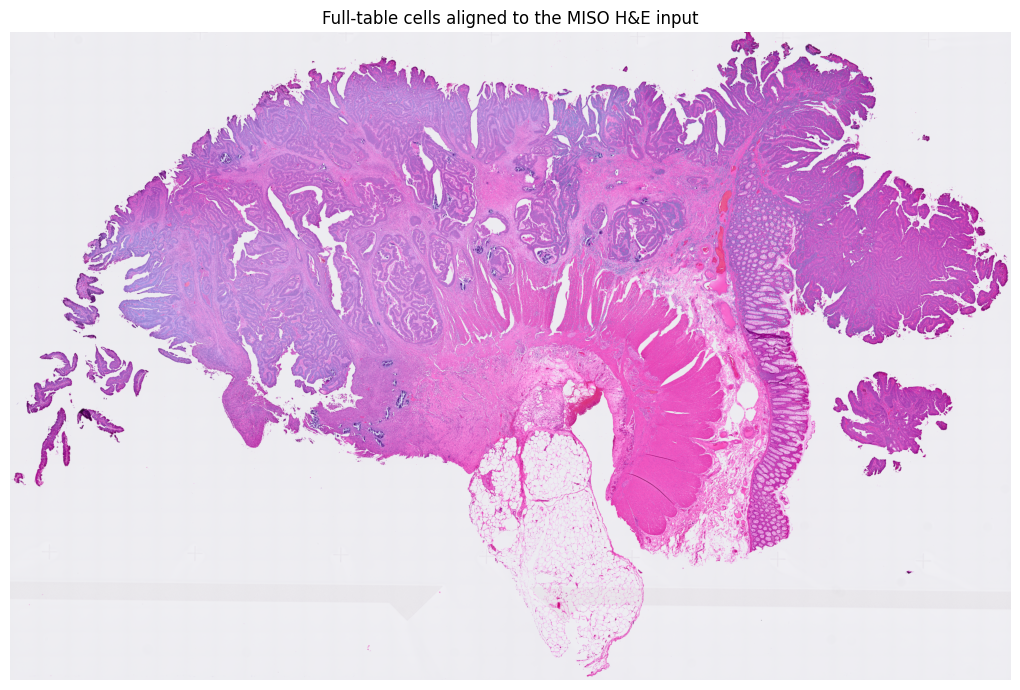

plot_input_and_he_alignment: 3.5 s (0.06 min); RSS delta +0.44 GB
time: 3.45 s (started: 2026-08-05 11:17:52 +01:00)


In [4]:
with record_step('plot_input_and_he_alignment'):
    he_image = np.asarray(Image.open(HE_IMAGE_PATH))
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.imshow(he_image)
    ax.scatter(
        adata.obsm['spatial_pixel'][:, 0],
        adata.obsm['spatial_pixel'][:, 1],
        s=0.05,
        c='cyan',
        alpha=0.18,
        linewidths=0,
        rasterized=True,
    )
    ax.set_title('Full-table cells aligned to the MISO H&E input')
    ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'miso_h_and_e_alignment_full_table.png', dpi=220, bbox_inches='tight')
    plt.show()


## 3. Full-run feasibility record

`sparse=True` is essential. Without it MISO calculates a dense pairwise affinity matrix;
for this data that matrix alone would require roughly 64.5 GB in float32. The sparse
graph avoids that allocation, but MISO's official training remains full-batch and has
no mini-batching or epoch argument. The values below are therefore recorded alongside
every result. Set `RUN_FULL_MISO=True` only for a deliberately scheduled full run.


In [ ]:
n_obs, n_hvgs = adata.shape
h_and_e_feature_dim = 576  # 192 global HIPT features + 384 local HIPT features in MISO.
print(f'RNA matrix dense float32: {n_obs * n_hvgs * 4 / 1024**3:.2f} GB')
print(f'Estimated H&E feature matrix float32: {n_obs * h_and_e_feature_dim * 4 / 1024**3:.2f} GB')
print(f'Dense affinity matrix float32 (DO NOT USE): {n_obs * n_obs * 4 / 1024**3:.2f} GB')
print('Sparse graph configuration for the official MISO class: 30 neighbours per modality.')

N_CLUSTERS = 7
SPARSE_NEIGHBORS = 30
RUN_FULL_MISO = True
FORCE_RERUN_MISO = False
RUN_ZARR_POSTPROCESS = False

RESULT_H5AD = RESULTS_DIR / 'miso_human_colon_full_2000hvg_results.h5ad'
FULL_RUN_TIMINGS_PATH = RESULTS_DIR / 'miso_full_run_timings.csv'

if RESULT_H5AD.exists() and not FORCE_RERUN_MISO:
    print('A completed full-table MISO result is available and will be reused:', RESULT_H5AD)
    print('Set FORCE_RERUN_MISO=True only when the embedding must be retrained from scratch.')
elif RUN_FULL_MISO:
    print('No reusable completed result found: the full MISO pipeline will run.')
else:
    print('Full MISO execution is disabled.')


## 4. Extract or reuse full-table H&E features

This is MISO's own HIPT feature extraction; it is not an additional preprocessing step.
It uses the supervisor-specified hires H&E image. On CPU, the official repository
estimates roughly two hours for H&E feature extraction on its example data; this larger
Visium HD image may take substantially longer. The cached `.npy` file prevents repeat work.


In [ ]:
IMAGE_FEATURES_PATH = RESULTS_DIR / 'miso_h_and_e_features_full_table.npy'
FULL_RUN_STATUS_PATH = RESULTS_DIR / 'miso_full_run_status.json'

def write_full_run_status(stage, **extra):
    payload = {
        'stage': stage,
        'updated_at': time.strftime('%Y-%m-%d %H:%M:%S %z'),
        'n_observations': int(adata.n_obs),
        'n_hvgs': int(adata.n_vars),
        'device': device,
    }
    payload.update(extra)
    FULL_RUN_STATUS_PATH.write_text(json.dumps(payload, indent=2))
    print('Full-run status:', stage, '->', FULL_RUN_STATUS_PATH)

reuse_completed_result = RESULT_H5AD.exists() and not FORCE_RERUN_MISO

if RUN_FULL_MISO and not reuse_completed_result:
    with record_step('miso_h_and_e_feature_extraction'):
        if IMAGE_FEATURES_PATH.exists():
            image_features = np.load(IMAGE_FEATURES_PATH, mmap_mode=None)
            print('Reused cached MISO H&E features:', image_features.shape)
            write_full_run_status('h_and_e_features_reused', feature_shape=list(image_features.shape))
        else:
            checkpoint_dir = MISO_REPO / 'miso' / 'checkpoints'
            checkpoints = [
                checkpoint_dir / 'vit256_small_dino.pth',
                checkpoint_dir / 'vit4k_xs_dino.pth',
            ]
            for checkpoint in checkpoints:
                if not checkpoint.exists() or checkpoint.stat().st_size < 1_000_000:
                    raise RuntimeError(f'Missing or incomplete MISO checkpoint: {checkpoint}')

            # Pixel coordinates were already mapped to the raw hires image during common input preparation.
            estimated_radius = float(input_metadata['estimated_cell_radius_pixels'])
            write_full_run_status(
                'h_and_e_feature_extraction_started',
                feature_cache=str(IMAGE_FEATURES_PATH),
                image_path=str(HE_IMAGE_PATH),
                estimated_radius_pixels=estimated_radius,
            )
            image_features = get_features(
                Image.open(HE_IMAGE_PATH),
                locs,
                rad=estimated_radius,
                pixel_size_raw=1.0,
                pixel_size=1.0,
                pretrained=True,
                device=device,
            ).astype(np.float32, copy=False)
            if image_features.shape[0] != adata.n_obs:
                raise RuntimeError('MISO H&E feature rows do not match full-table observations.')
            np.save(IMAGE_FEATURES_PATH, image_features)
            write_full_run_status('h_and_e_feature_extraction_complete', feature_shape=list(image_features.shape))
            print('Saved MISO H&E features:', IMAGE_FEATURES_PATH, image_features.shape)
elif reuse_completed_result:
    print('Skipping H&E extraction because the completed full-table embedding is being reused.')


## 5. Run MISO with RNA plus H&E features

No `miso.utils.preprocess()` call is made: the supervisor specified no extra expression
preprocessing after the common 2,000-HVG selection. MISO itself standardizes each view,
constructs its sparse affinity graph, trains one autoencoder per modality, then learns
individual and cross-modality interaction embeddings. `sparse=True` is the official
MISO option used for the full-table feasibility case.


In [ ]:
reuse_completed_result = RESULT_H5AD.exists() and not FORCE_RERUN_MISO

if reuse_completed_result:
    with record_step('load_cached_full_miso_result'):
        adata = sc.read_h5ad(RESULT_H5AD)
        if adata.shape != (131592, 2000):
            raise RuntimeError(f'Cached result has the wrong shape: {adata.shape}')
        if 'X_miso' not in adata.obsm or adata.obsm['X_miso'].shape != (131592, 96):
            raise RuntimeError('Cached result does not contain the expected full-table MISO embedding.')

        # MISO's embedding is independent of k. Re-clustering a cached embedding uses
        # the exact KMeans call in Miso.cluster(), without repeating the 2,000-epoch training.
        cached_k = adata.obs['miso_domains'].nunique() if 'miso_domains' in adata.obs else None
        if cached_k != N_CLUSTERS:
            miso_domains = KMeans(N_CLUSTERS, random_state=100).fit_predict(adata.obsm['X_miso'])
            adata.obs['miso_domains'] = pd.Categorical(miso_domains.astype(str))
            print(f'Re-clustered the completed MISO embedding from k={cached_k} to k={N_CLUSTERS}.')
        else:
            print(f'Reused completed full-table MISO embedding and k={cached_k} labels.')

elif RUN_FULL_MISO:
    write_full_run_status(
        'miso_model_pipeline_started',
        n_clusters=int(N_CLUSTERS),
        sparse_neighbors=int(SPARSE_NEIGHBORS),
    )
    with record_step('materialise_rna_for_miso'):
        rna_features = (
            adata.X.toarray().astype(np.float32, copy=False)
            if sp_sparse.issparse(adata.X)
            else np.asarray(adata.X, dtype=np.float32)
        )
        print('RNA feature matrix supplied to MISO:', rna_features.shape, rna_features.dtype)

    with record_step('miso_graph_and_model_initialisation'):
        model = Miso(
            [rna_features, image_features],
            ind_views='all',
            combs='all',
            sparse=True,
            neighbors=SPARSE_NEIGHBORS,
            device=device,
        )
    del rna_features

    with record_step('miso_model_training'):
        model.train()

    with record_step('miso_clustering'):
        miso_domains = model.cluster(n_clusters=N_CLUSTERS)
        adata.obs['miso_domains'] = pd.Categorical(miso_domains.astype(str))
        adata.obsm['X_miso'] = model.emb.astype(np.float32, copy=False)

    # Persist the expensive result immediately, before plotting or optional post-processing.
    adata.write_h5ad(RESULT_H5AD, compression='gzip')
    write_full_run_status('miso_clustering_complete', embedding_shape=list(adata.obsm['X_miso'].shape))
else:
    print('MISO training was not run and no completed result was loaded.')

if 'miso_domains' in adata.obs:
    domain_counts = adata.obs['miso_domains'].value_counts().sort_index()
    print('MISO embedding:', adata.obsm['X_miso'].shape)
    print(domain_counts)
    if int(domain_counts.min()) < 10:
        print('WARNING: at least one requested domain contains fewer than 10 observations. '
              'This is an official-KMeans output characteristic and must be reported, not hidden.')


## 6. Plot MISO spatial domains and compare with the expression-only reference

The left panel is the existing expression-only Leiden reference (`clusters_res_1_5`),
and the right panel is MISO's RNA + H&E spatial-domain output. The H&E overlay provides
a direct morphological interpretation of MISO boundaries.


In [ ]:
if 'miso_domains' not in adata.obs and RESULT_H5AD.exists():
    adata = sc.read_h5ad(RESULT_H5AD)

if 'miso_domains' in adata.obs:
    with record_step('plot_miso_domains'):
        pixel_xy = adata.obsm['spatial_pixel']
        fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)
        axes[0].scatter(
            adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1],
            c=adata.obs['clusters_res_1_5'].astype(str).astype('category').cat.codes,
            s=0.12, cmap='tab20', linewidths=0, rasterized=True,
        )
        axes[0].set_title('Expression-only reference: Leiden res 1.5')
        axes[0].set_aspect('equal')
        axes[0].invert_yaxis()
        axes[0].set_axis_off()

        axes[1].imshow(he_image, alpha=0.68)
        scatter = axes[1].scatter(
            pixel_xy[:, 0], pixel_xy[:, 1],
            c=adata.obs['miso_domains'].astype(str).astype('category').cat.codes,
            s=0.14, cmap='tab10', linewidths=0, alpha=0.86, rasterized=True,
        )
        axes[1].set_title(f'MISO spatial domains: RNA + H&E (k={N_CLUSTERS})')
        axes[1].set_axis_off()
        fig.savefig(RESULTS_DIR / 'miso_domains_vs_expression_reference.png', dpi=260, bbox_inches='tight')
        plt.show()
else:
    print('Run the full MISO cells first; this plotting cell does not create a substitute subset result.')


## 7. Save benchmark outputs and optional SpatialData zarr

The H5AD, labels, embedding, plots, parameter manifest, and stage-level timings are
MISO method outputs. The zarr write is done by a Python 3.11 helper because SpatialData
is incompatible with MISO's required Python 3.7; it is clearly separated from MISO runtime.


In [ ]:
if 'miso_domains' in adata.obs:
    with record_step('save_miso_method_outputs'):
        labels_path = RESULTS_DIR / 'miso_domain_labels.csv'
        embedding_path = RESULTS_DIR / 'miso_embedding.npy'
        timing_path = RESULTS_DIR / 'miso_notebook_session_timings.csv'
        run_metadata_path = RESULTS_DIR / 'miso_run_metadata.json'

        adata.write_h5ad(RESULT_H5AD, compression='gzip')
        adata.obs[['miso_domains']].to_csv(labels_path)
        np.save(embedding_path, adata.obsm['X_miso'])
        pd.DataFrame(step_times).to_csv(timing_path, index=False)
        run_metadata = {
            'method': 'MISO',
            'analysis_table': 'manual_analysis_count_area_filtered',
            'n_observations': int(adata.n_obs),
            'n_hvgs': int(adata.n_vars),
            'n_clusters': int(N_CLUSTERS),
            'sparse_graph': True,
            'sparse_neighbors': int(SPARSE_NEIGHBORS),
            'device': device,
            'input_metadata': input_metadata,
            'note': 'No expression preprocessing beyond the shared 2,000-HVG input selection.',
        }
        run_metadata_path.write_text(json.dumps(run_metadata, indent=2))
        print('Saved:', RESULT_H5AD)
        print('Saved:', labels_path)
        print('Saved:', embedding_path)
        print('Saved:', timing_path)

    if RUN_ZARR_POSTPROCESS:
        zarr_output = RESULTS_DIR / 'miso_human_colon_full_2000hvg.spatialdata.zarr'
        zarr_manifest = RESULTS_DIR / 'miso_zarr_postprocess_manifest.json'
        command = [
            '/Users/zhuzhengyang/anaconda3/envs/python3.11_SPARTAN/bin/python',
            '/Users/zhuzhengyang/Desktop/HDS_Dissertation/MISO/attach_miso_domains_to_sdata.py',
            '--source-zarr', input_metadata['source_zarr'],
            '--labels', str(labels_path),
            '--embedding', str(embedding_path),
            '--output-zarr', str(zarr_output),
            '--metadata', str(zarr_manifest),
        ]
        print('Running post-processing:', ' '.join(command))
        subprocess.run(command, check=True)
else:
    print('No MISO domains are available yet, so no result files were written.')


## Interpretation checklist

- Verify that MISO domains form spatially coherent regions and that boundary changes are plausible on H&E.
- Compare domain count and area with the expression-only Leiden reference, but do not interpret matching label IDs as biological equivalence.
- Use `miso_stage_timings.csv` to report feature extraction, graph construction, training, clustering, and output time separately.
- Report the sparse-graph setting, neighbour count, device, and MISO's full-batch limitation in the benchmark methods table.


## Debug validation record

The full-table run completed successfully on CPU on 13 August 2026. It used all
**131,592 observations**, the shared **2,000 HVGs**, and **576 H&E features** per
observation. The resulting MISO embedding has shape **131,592 x 96** and contains no
NaN or infinite values.

Recorded method-stage runtime was approximately **94.3 minutes**: H&E feature extraction
36.4 min, sparse-graph/model initialisation 18.3 min, official MISO training 39.5 min,
and k=7 clustering 0.07 min. See `miso_full_run_timings.csv` for the machine-readable
record.

The official k=7 KMeans result is highly imbalanced: two labels contain one observation
each. This is a result-quality finding rather than an execution failure. Keep it visible
in the benchmark and assess it with the planned spatial-coherence and biological-marker
validation metrics.
